## Vizualizing Word Frequencies with Pandas

* We will visualize the most 20 frequent words in Hamlet using a pandas bar chart.

### Launch Matplotlib

In [84]:
%matplotlib inline

### Download NLTK libraries

*   These libraries must be downloaded first before use.



In [85]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### Download the Hamlet Text

* Send a GET request to retrieve the contents of the text file
* Load it into a TextBlob object for later text processing

In [86]:
!pip install requests

import requests

target_url ='https://www.gutenberg.org/files/2265/2265-0.txt'
response = requests.get(target_url)
data = response.text

from textblob import TextBlob

blob = TextBlob(data)

### Load NLTK stopwords

In [87]:
from nltk.corpus import stopwords

stop_words = stopwords.words('english')

### Getting the Word Frequencies

* Get word frequencies using the `blob.word_counts` dictionary's `items` method.
* Remove the stop words from the dictionary.

In [88]:
items = blob.word_counts.items()

items = [item for item in items if item[0] not in stop_words]

### Sorting the Words by Frequency

* Sort the items by most frequent words to least frequent using the built-in `sorted` function.
* Use `itemgetter` to access the element at index 1 for each tuple, which will be used as the sort key.
* `reverse=True` means that the items should be sorted in descending order.

In [89]:
from operator import itemgetter

sorted_items = sorted(items, key=itemgetter(1), reverse=True)

### Getting the Top 20 Words

In [90]:
top_20 = sorted_items[0:20]

print(top_20)

[('ham', 337), ('lord', 211), ('haue', 175), ('king', 173), ('shall', 107), ('come', 106), ('thou', 105), ('let', 104), ('hamlet', 100), ('good', 98), ('hor', 95), ('thy', 90), ('enter', 85), ('oh', 81), ('like', 78), ('well', 70), ('may', 69), ('know', 69), ('selfe', 68), ('would', 68)]


### Visualizing the Data

* First convert the data to a pandas DataFrame.
* Display using the `bar` method of DataFrame's `plot` property.

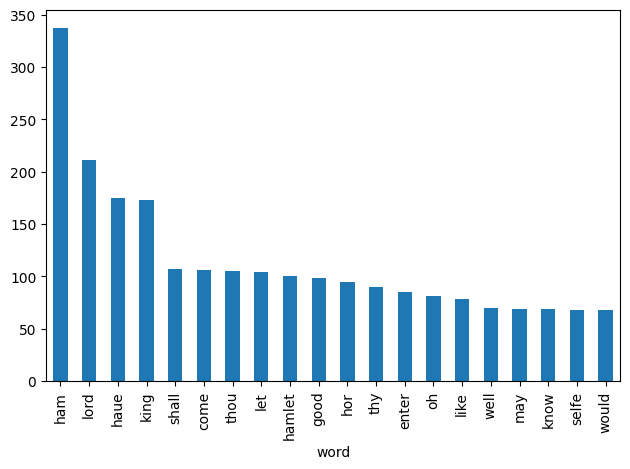

In [91]:
import pandas as pd

df = pd.DataFrame(top_20, columns=['word', 'count'])

axes = df.plot.bar(x='word', y='count', legend=False)

import matplotlib.pyplot as plt

plt.gcf().tight_layout()

## Visualizing Word Frequencies with Word Clouds

* By default, this shows the top 200 words.

### Import the oval mask

In [92]:
import imageio

image_file="https://media.cheggcdn.com/media/216/21621ee5-e80f-47f3-9145-513f2229b390/phploeBuh.png"

mask_image = imageio.v3.imread(image_file)

### Configure the WordCloud Object

In [93]:
from wordcloud import WordCloud

wordcloud = WordCloud(colormap='prism', mask=mask_image,
                      background_color='white', width=800, height=400)

### Generate the Word Cloud

* We will use the `data` variable from the earlier exercise for the Hamlet text.

In [94]:
wordcloud = wordcloud.generate(data)

### Display the Image

(np.float64(-0.5), np.float64(1023.5), np.float64(591.5), np.float64(-0.5))

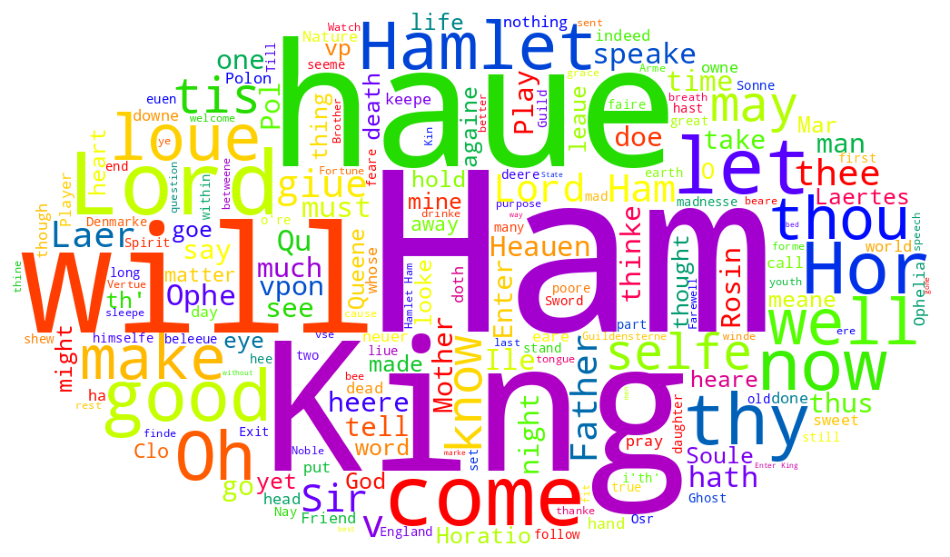

In [95]:
plt.figure(figsize=(12, 12), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")